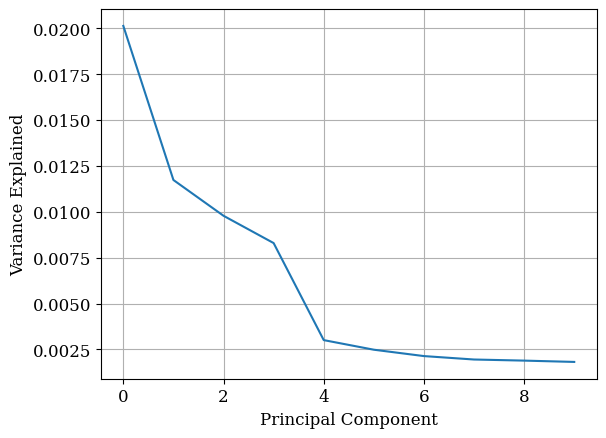

In [1]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import numpy as np
import pandas as pd
import pickle
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.gaussian_process.kernels import RBF
import logging
import matplotlib.pyplot as plt
logging.getLogger('matplotlib.font_manager').disabled = True
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

import umap
from sklearn.decomposition import PCA

seed = 0
np.random.seed(seed)

dataset = sc.datasets.pbmc3k_processed()
X_raw = dataset.X
# X = dataset.obsm['X_pca']
# X = datset.obsm['X_umap']
pca = PCA(n_components=10).fit(X_raw)
X_pca = pca.transform(X_raw)

plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid()

In [ ]:
X = umap.UMAP(n_neighbors=30, min_dist=0.3, n_components=4, random_state=seed).fit_transform(X_pca)
F_names = list(dataset.var.index)
F = dataset.X

categories = list(dataset.obs['louvain'].cat.categories)
cell_types = list(dataset.obs['louvain'])
cell_types_ints = np.array([categories.index(cell_type) for cell_type in cell_types])

fig, ax = plt.subplots(2, 3, figsize=(12,6))
ax[0, 0].scatter(X[:, 0], X[:, 1], c = cell_types_ints, cmap='tab10')
ax[0, 1].scatter(X[:, 0], X[:, 2], c = cell_types_ints, cmap='tab10')
ax[0, 2].scatter(X[:, 0], X[:, 3], c = cell_types_ints, cmap='tab10')
ax[1, 0].scatter(X[:, 1], X[:, 2], c = cell_types_ints, cmap='tab10')
ax[1, 1].scatter(X[:, 1], X[:, 3], c = cell_types_ints, cmap='tab10')
sc = ax[1, 2].scatter(X[:, 2], X[:, 3], c = cell_types_ints, cmap='tab10')
fig.legend(sc.legend_elements()[0], categories, loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle('2-D views of UMAP (d=4)')

In [ ]:
r = 1.0
knn = 128
neighbor_graph = kneighbors_graph(X, knn, include_self=True)

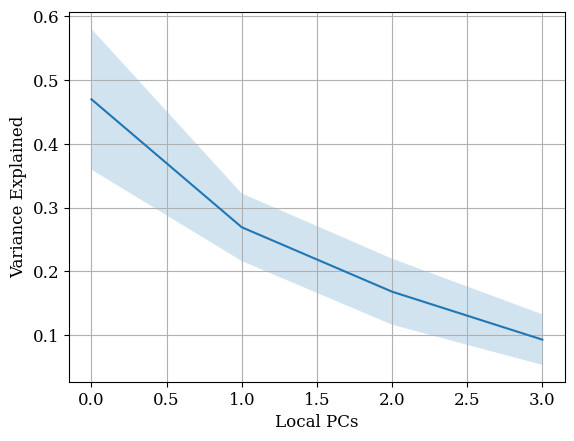

In [4]:
var_explained_ratios = []
for index in range(X.shape[0]):
    nbr_ind = neighbor_graph[index].nonzero()[1]
    pca = PCA(n_components=4).fit(X[nbr_ind])
    local_var = pca.explained_variance_ratio_
    var_explained_ratios.append(local_var)
var_explained_ratios = np.stack(var_explained_ratios)
mean_var_explained = np.mean(var_explained_ratios, axis=0)
std_var_explained = np.std(var_explained_ratios, axis=0)
plt.plot(mean_var_explained)
plt.fill_between(range(len(mean_var_explained)), mean_var_explained - std_var_explained, mean_var_explained + std_var_explained, alpha=0.2)
plt.xlabel('Local PCs')
plt.ylabel('Variance Explained')
plt.grid()

In [ ]:
import sys
sys.path.append('../')
from lego import lego

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import MultiTaskElasticNet

from local_ts_regression import lpca, run_ts_regression_smoothed

d = 2

trivial_basis = np.stack([np.eye(X.shape[1])] * X.shape[0], axis=0)
lpca_basis = lpca(X, d, neighbor_graph)
wlpca_basis = lpca(X, d, neighbor_graph, r=1.0)

ts_method = 'lego'
n_eig_for_grad = 40
n_eig = 100
lego_estimate = lego.lego(
    X,
    opts={'emb_dim': d, 'k_nn': knn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)
lego_basis = lego_estimate['tang_basis']

Cell Type: NK cells
Support Features: ['HOPX', 'PRF1']


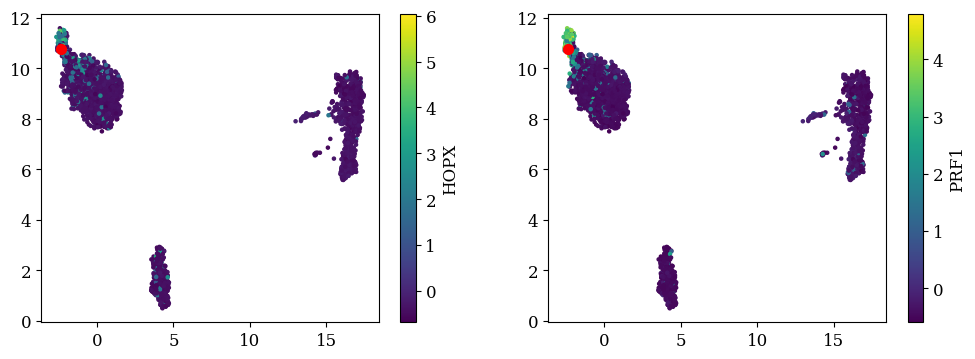

In [ ]:
index = 4

n_feats = 2
# tsbasis = trivial_basis
# tsbasis = lpca_basis
# tsbasis = wlpca_basis
tsbasis = lego_basis

normalizer = StandardScaler(with_mean=False)
regressor = MultiTaskElasticNet(alpha=0.1, l1_ratio=0.5, fit_intercept=False, tol=1e-2)

cell_type = cell_types[index]
print(f'Cell Type: {cell_type}')
reg_coefs, proj = run_ts_regression_smoothed(X, F, index, neighbor_graph, tsbasis, regressor=regressor, gamma=1.0, k=1)
strengths = np.linalg.norm(reg_coefs, axis=0)
support = np.argsort(strengths)[-1:-n_feats-1:-1]
fig, ax = plt.subplots(1, len(support), figsize=(6*len(support), 4))
for i in range(len(support)):
    sc = ax[i].scatter(X[:, 0], X[:, 1], c = F[:,support[i]], s=5, cmap='viridis')
    ax[i].scatter(X[index, 0], X[index, 1], c = 'red', s=50)
    fig.colorbar(sc, ax=ax[i], label=F_names[support[i]])
print(f'Support Features: {[F_names[i] for i in support]}')

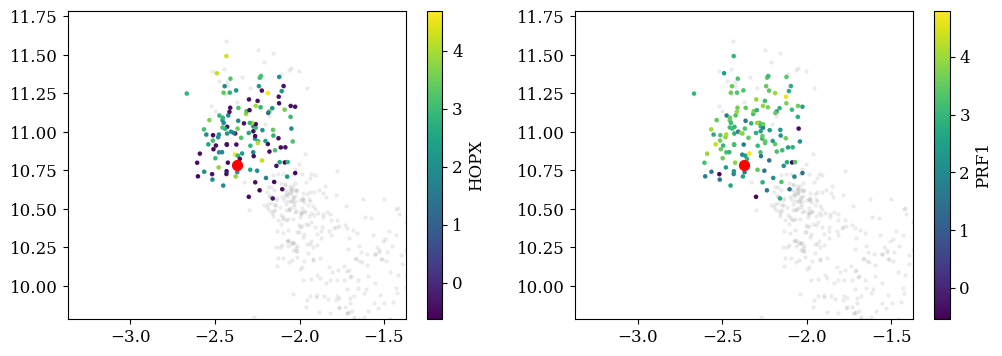

In [12]:
nbr_ind = neighbor_graph[index].nonzero()[1]
fig, ax = plt.subplots(1, len(support), figsize=(6*len(support), 4))
for i in range(len(support)):
    ax[i].scatter(X[:, 0], X[:, 1], c = 'gray', s=5, alpha=0.1)
    sc = ax[i].scatter(X[nbr_ind, 0], X[nbr_ind, 1], c = F[nbr_ind,support[i]], s=5, cmap='viridis')
    ax[i].scatter(X[index, 0], X[index, 1], c = 'red', s=50)
    ax[i].set_xlim(X[index, 0] - 1.0, X[index, 0] + 1.0)
    ax[i].set_ylim(X[index, 1] - 1.0, X[index, 1] + 1.0)
    fig.colorbar(sc, ax=ax[i], label=F_names[support[i]])

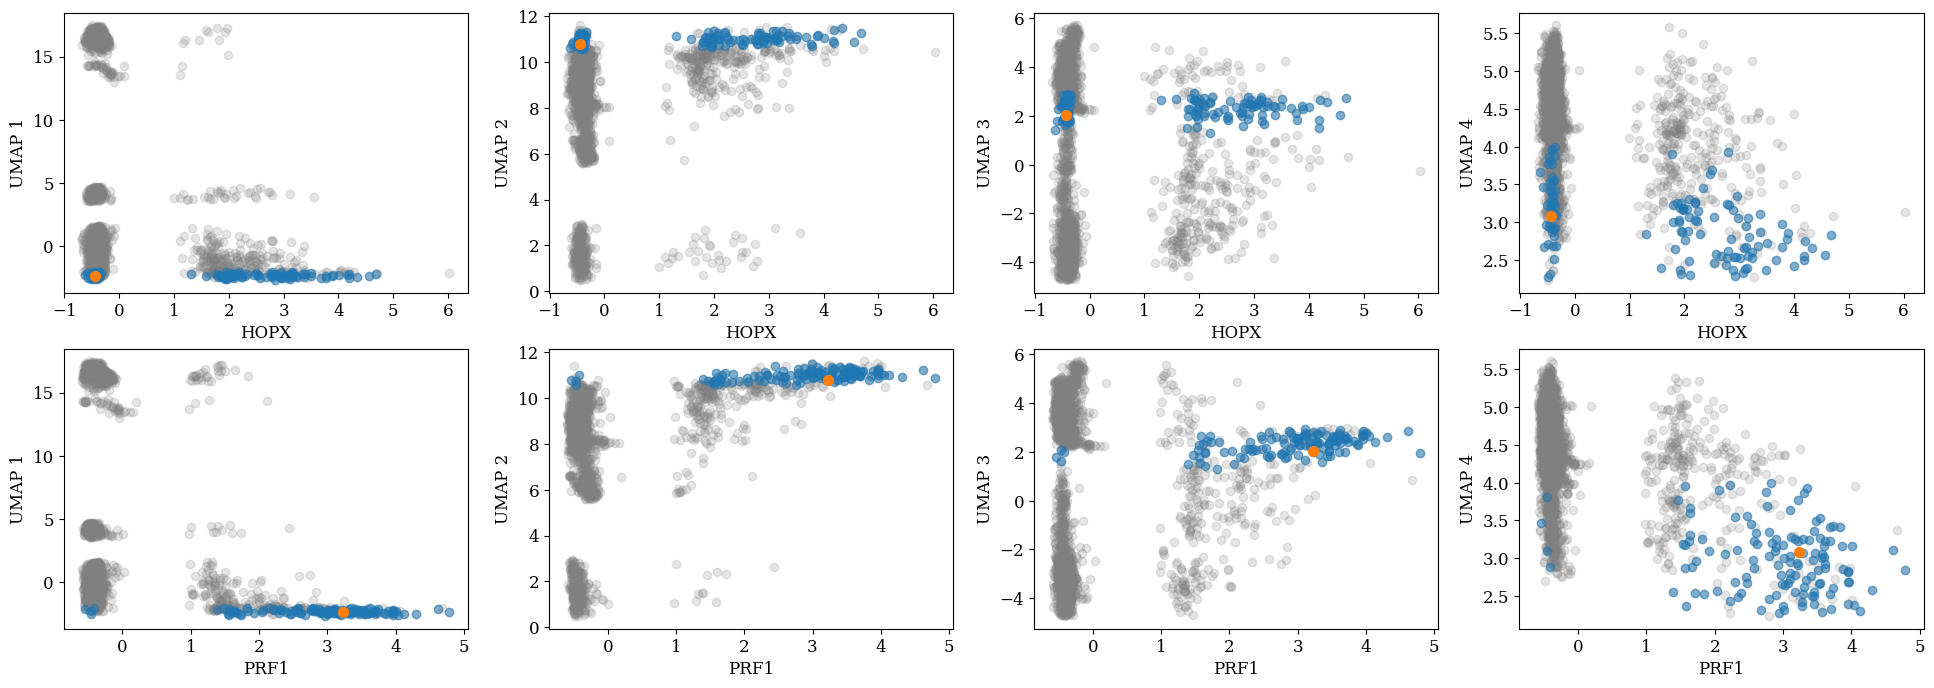

In [13]:
fig, ax = plt.subplots(len(support), X.shape[1], figsize=(6*X.shape[1], 4*len(support)))
for i in range(X.shape[1]):
    for j in range(len(support)):
        ax[j, i].scatter(F[:,support[j]], X[:,i], alpha=0.2, c='grey')
        nbr_ind = neighbor_graph[index].nonzero()[1]
        ax[j, i].scatter(F[nbr_ind,support[j]], X[nbr_ind,i], alpha=0.5)
        ax[j, i].scatter(F[index,support[j]], X[index,i], s=50)
        ax[j, i].set_ylabel(f'UMAP {i+1}')
        ax[j, i].set_xlabel(F_names[support[j]])

/tmp/ipykernel_1933022/4241906187.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


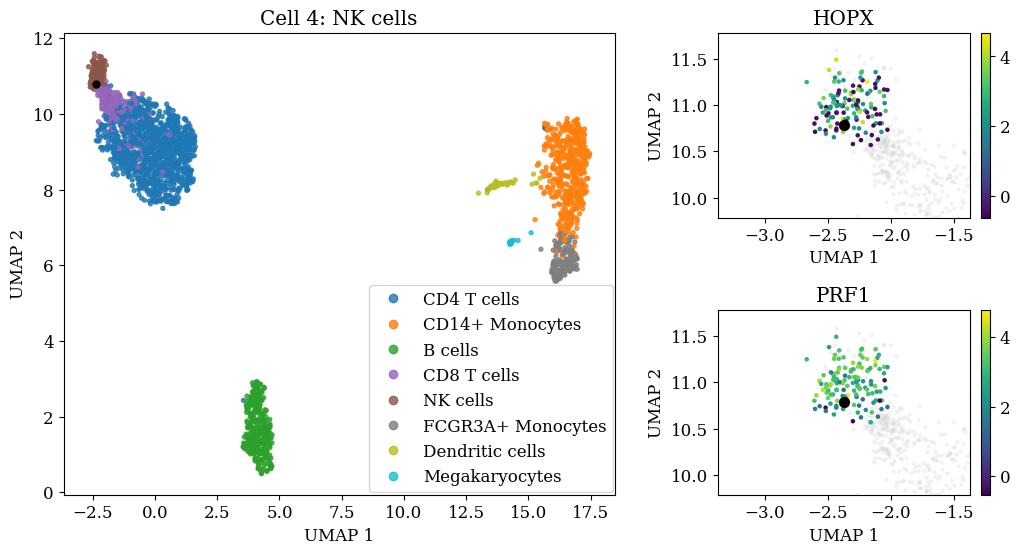

In [14]:
# Large-left + two-small-right layout
window = 1.0
x0, y0 = X[index, 0], X[index, 1]

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], wspace=0.25, hspace=0.5)

# Left: full UMAP (top 2 dims), colored by cell type
ax_left = fig.add_subplot(gs[:, 0])
sc_left = ax_left.scatter(X[:, 0], X[:, 1], c=cell_types_ints, cmap="tab10", s=8, alpha=0.8)
ax_left.scatter(x0, y0, c="black", s=25, zorder=5)
ax_left.set_xlabel("UMAP 1")
ax_left.set_ylabel("UMAP 2")
ax_left.set_title(f"Cell {index}: {cell_type}")
handles = sc_left.legend_elements()[0]
ax_left.legend(handles, categories, loc="center left", bbox_to_anchor=(0.54, 0.23), frameon=True)

# Window mask around indexed cell in top-2 UMAP coordinates
mask = (
    (X[:, 0] >= x0 - window) & (X[:, 0] <= x0 + window) &
    (X[:, 1] >= y0 - window) & (X[:, 1] <= y0 + window)
)
neighbor_mask = np.zeros(X.shape[0], dtype=bool)
neighbor_mask[neighbor_graph[index].nonzero()[1]] = True
# Right: two small panels colored by selected support functions
for k in range(min(2, len(support))):
    ax_r = fig.add_subplot(gs[k, 1])
    feat_idx = support[k]

    # background + local window colored by feature value
    ax_r.scatter(X[mask, 0], X[mask, 1], c="lightgray", s=5, alpha=0.2)
    sc_r = ax_r.scatter(X[neighbor_mask, 0], X[neighbor_mask, 1], c=F[neighbor_mask, feat_idx], cmap="viridis", s=5)
    ax_r.scatter(x0, y0, c="black", s=50, zorder=5)

    ax_r.set_xlim(x0 - window, x0 + window)
    ax_r.set_ylim(y0 - window, y0 + window)
    ax_r.set_xlabel("UMAP 1")
    ax_r.set_ylabel("UMAP 2")
    ax_r.set_title(f"{F_names[feat_idx]}")
    fig.colorbar(sc_r, ax=ax_r, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(f'../images/pbmc_explanation_{index}.png', dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1933022/4244458794.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


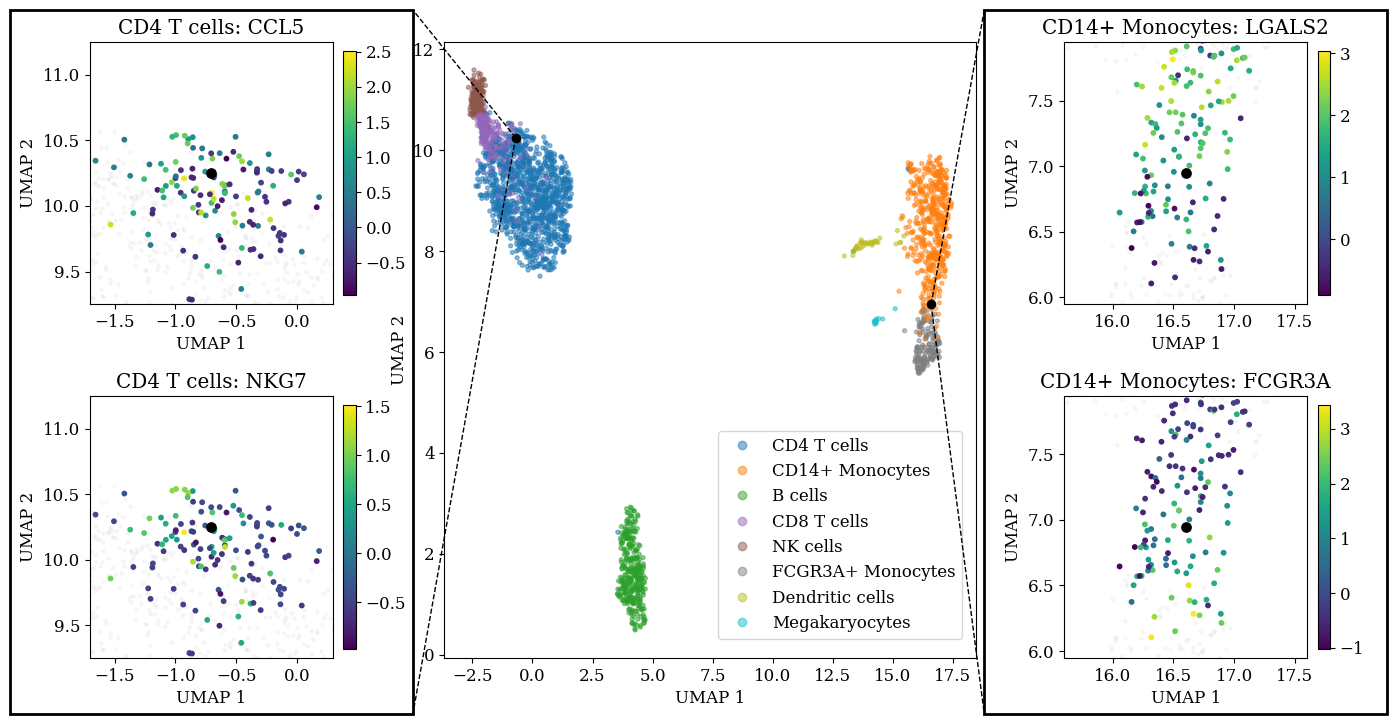

Cell 0 selected genes: ['CCL5', 'NKG7']
Cell 3 selected genes: ['LGALS2', 'FCGR3A']


In [15]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Compute selected genes for cell 0 and cell 3 (top-n by regression strength)
n_feats = 2
window = 1.0

def get_support(cell_idx, n_feats=2, gamma=1.0, k=1):
    reg_coefs_i, _ = run_ts_regression_smoothed(
        X, F, cell_idx, neighbor_graph, tsbasis, regressor=regressor, gamma=gamma, k=k
    )
    strengths_i = np.linalg.norm(reg_coefs_i, axis=0)
    return np.argsort(strengths_i)[-1:-n_feats-1:-1]

support0 = get_support(0, n_feats=n_feats)
support3 = get_support(3, n_feats=n_feats)

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 2, 1], wspace=0.25, hspace=0.35)

# Center: full UMAP colored by cell type
ax_center = fig.add_subplot(gs[:, 1])
sc_center = ax_center.scatter(X[:, 0], X[:, 1], c=cell_types_ints, cmap="tab10", s=8, alpha=0.5)
ax_center.scatter(X[0, 0], X[0, 1], c="black", s=35, marker="o", label="cell 0", zorder=5)
ax_center.scatter(X[3, 0], X[3, 1], c="black", s=35, marker="o", label="cell 3", zorder=5)
ax_center.set_xlabel("UMAP 1")
ax_center.set_ylabel("UMAP 2")
# ax_center.set_title("Full UMAP")
handles = sc_center.legend_elements()[0]
ax_center.legend(handles, categories, loc="center left", bbox_to_anchor=(0.5, 0.2), frameon=True)

def plot_window(ax, cell_idx, feat_idx, side_label):
    x0, y0 = X[cell_idx, 0], X[cell_idx, 1]
    mask = (
        (X[:, 0] >= x0 - window) & (X[:, 0] <= x0 + window) &
        (X[:, 1] >= y0 - window) & (X[:, 1] <= y0 + window)
    )
    nbr_mask = neighbor_graph[cell_idx].nonzero()[1]

    ax.scatter(X[mask, 0], X[mask, 1], c="lightgray", s=5, alpha=0.15)
    sc_local = ax.scatter(X[nbr_mask, 0], X[nbr_mask, 1], c=F[nbr_mask, feat_idx], cmap="viridis", s=10)
    ax.scatter(x0, y0, c="black", s=45, zorder=5)

    ax.set_xlim(x0 - window, x0 + window)
    ax.set_ylim(y0 - window, y0 + window)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(f"{side_label}: {F_names[feat_idx]}")
    fig.colorbar(sc_local, ax=ax, fraction=0.046, pad=0.04)

# Left: two windows for cell 0
ax_l0 = fig.add_subplot(gs[0, 0])
ax_l1 = fig.add_subplot(gs[1, 0])
plot_window(ax_l0, 0, support0[0], cell_types[0])
plot_window(ax_l1, 0, support0[1], cell_types[0])

# Right: two windows for cell 3
ax_r0 = fig.add_subplot(gs[0, 2])
ax_r1 = fig.add_subplot(gs[1, 2])
plot_window(ax_r0, 3, support3[0], cell_types[3])
plot_window(ax_r1, 3, support3[1], cell_types[3])

cid = [None]
def _on_draw(event):
    # Left windows rectangle + connectors (cell 0)
    pos0 = ax_l0.get_position()
    pos1 = ax_l1.get_position()
    xpad = 0.05
    x0f = max(0, min(pos0.x0, pos1.x0) - xpad)
    y0f = max(0, min(pos0.y0, pos1.y0) - 0.07)
    x1f = min(1, max(pos0.x1, pos1.x1) + xpad)
    y1f = min(1, max(pos0.y1, pos1.y1) + 0.04)
    w, h = x1f - x0f, y1f - y0f

    rect = Rectangle((x0f, y0f), w, h, transform=fig.transFigure,
                     fill=False, edgecolor='black', linewidth=2, zorder=6)
    fig.add_artist(rect)

    cell_disp0 = ax_center.transData.transform((X[0, 0], X[0, 1]))
    cell_fig0 = fig.transFigure.inverted().transform(cell_disp0)
    top = (x0f + w, y0f + h)
    bottom = (x0f + w, y0f)

    l1 = Line2D([cell_fig0[0], top[0]], [cell_fig0[1], top[1]],
                transform=fig.transFigure, color='black', linewidth=1, linestyle='--', zorder=5)
    l2 = Line2D([cell_fig0[0], bottom[0]], [cell_fig0[1], bottom[1]],
                transform=fig.transFigure, color='black', linewidth=1, linestyle='--', zorder=5)
    fig.add_artist(l1)
    fig.add_artist(l2)

    # Right windows rectangle + connectors (cell 3)
    pos2 = ax_r0.get_position()
    pos3 = ax_r1.get_position()
    xpad2 = 0.05
    x0f2 = max(0, min(pos2.x0, pos3.x0) - xpad2)
    y0f2 = max(0, min(pos2.y0, pos3.y0) - 0.07)
    x1f2 = min(1, max(pos2.x1, pos3.x1) + xpad2)
    y1f2 = min(1, max(pos2.y1, pos3.y1) + 0.04)
    w2, h2 = x1f2 - x0f2, y1f2 - y0f2

    rect2 = Rectangle((x0f2, y0f2), w2, h2, transform=fig.transFigure,
                      fill=False, edgecolor='black', linewidth=2, zorder=6)
    fig.add_artist(rect2)

    cell_disp3 = ax_center.transData.transform((X[3, 0], X[3, 1]))
    cell_fig3 = fig.transFigure.inverted().transform(cell_disp3)
    top2 = (x0f2, y0f2 + h2)    # left edge of right-rectangle
    bottom2 = (x0f2, y0f2)

    l3 = Line2D([cell_fig3[0], top2[0]], [cell_fig3[1], top2[1]],
                transform=fig.transFigure, color='black', linewidth=1, linestyle='--', zorder=5)
    l4 = Line2D([cell_fig3[0], bottom2[0]], [cell_fig3[1], bottom2[1]],
                transform=fig.transFigure, color='black', linewidth=1, linestyle='--', zorder=5)
    fig.add_artist(l3)
    fig.add_artist(l4)

    fig.canvas.mpl_disconnect(cid[0])

cid[0] = fig.canvas.mpl_connect('draw_event', _on_draw)

# fig.suptitle("Local gene windows (cell 0 vs cell 3) with global UMAP context", y=1.02)
fig.tight_layout()
plt.savefig('../images/pbmc_explanation_composite.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cell 0 selected genes:", [F_names[i] for i in support0])
print("Cell 3 selected genes:", [F_names[i] for i in support3])